# ✅ Notebook 5: Validación Robusta y Reporte Final
## Dataset: Medical Cost Personal Dataset

**Objetivo:** Validar robustamente los tres modelos usando Cross-Validation, reportar métricas en el Test set, analizar residuales y comparar el desempeño final.

**Técnicas:**
- KFold Cross-Validation (k=5 y k=10)
- Learning Curves
- Análisis de residuales
- Comparación de métricas: RMSE, MSE, MAE, R²
- Intervalos de confianza para las métricas

In [1]:
# ─────────────────────────────────────────
# IMPORTACIONES
# ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    cross_val_score, cross_validate, KFold, learning_curve
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)

def rmse(y_true, y_pred): return np.sqrt(mean_squared_error(y_true, y_pred))

def full_metrics(y_true, y_pred):
    return {
        'RMSE': rmse(y_true, y_pred),
        'MSE':  mean_squared_error(y_true, y_pred),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred)
    }

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 1. Carga de Modelos y Datos

In [2]:
# Cargar modelos entrenados
lr_model  = joblib.load('../models/linear_regression.pkl')
knn_model = joblib.load('../models/knn_regressor.pkl')
rf_model  = joblib.load('../models/random_forest.pkl')

# Cargar datos
X_train    = pd.read_csv('../data/processed/X_train_selected.csv')
X_test     = pd.read_csv('../data/processed/X_test_selected.csv')
X_train_sc = pd.read_csv('../data/processed/X_train_scaled_selected.csv')
X_test_sc  = pd.read_csv('../data/processed/X_test_scaled_selected.csv')
y_train    = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test     = pd.read_csv('../data/processed/y_test.csv').squeeze()
y_raw_test = pd.read_csv('../data/processed/y_raw_test.csv').squeeze()
y_raw_train= pd.read_csv('../data/processed/y_raw_train.csv').squeeze()

models = {
    'Reg. Lineal': (lr_model, X_train_sc, X_test_sc),
    'KNN':         (knn_model, X_train_sc, X_test_sc),
    'Random Forest': (rf_model, X_train, X_test)
}

print('✅ Modelos y datos cargados correctamente')
print(f'📦 X_train: {X_train.shape} | X_test: {X_test.shape}')

✅ Modelos y datos cargados correctamente
📦 X_train: (1069, 7) | X_test: (268, 7)


## 2. Cross-Validation Completo (KFold 5 y 10)

In [3]:
# ─────────────────────────────────────────
# CROSS-VALIDATION — Múltiples métricas
# ─────────────────────────────────────────
cv5  = KFold(n_splits=5,  shuffle=True, random_state=42)
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'r2':   'r2',
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae':  'neg_mean_absolute_error',
    'neg_mse':  'neg_mean_squared_error'
}

cv_results = {}

print('📊 Ejecutando Cross-Validation...')
print('-'*60)

for name, (model, X_tr, X_te) in models.items():
    print(f'\n🔄 {name}...')
    cv_res = cross_validate(model, X_tr, y_train, cv=cv5, scoring=scoring, n_jobs=-1)
    cv_results[name] = cv_res
    
    rmse_scores = -cv_res['test_neg_rmse']
    r2_scores   =  cv_res['test_r2']
    mae_scores  = -cv_res['test_neg_mae']
    
    print(f'  RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}')
    print(f'  MAE:  {mae_scores.mean():.4f} ± {mae_scores.std():.4f}')
    print(f'  R²:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}')

📊 Ejecutando Cross-Validation...
------------------------------------------------------------

🔄 Reg. Lineal...
  RMSE: 0.4202 ± 0.0189
  MAE:  0.2490 ± 0.0102
  R²:   0.7826 ± 0.0277

🔄 KNN...
  RMSE: 0.4249 ± 0.0180
  MAE:  0.2578 ± 0.0150
  R²:   0.7780 ± 0.0258

🔄 Random Forest...
  RMSE: 0.4122 ± 0.0228
  MAE:  0.2291 ± 0.0122
  R²:   0.7902 ± 0.0328


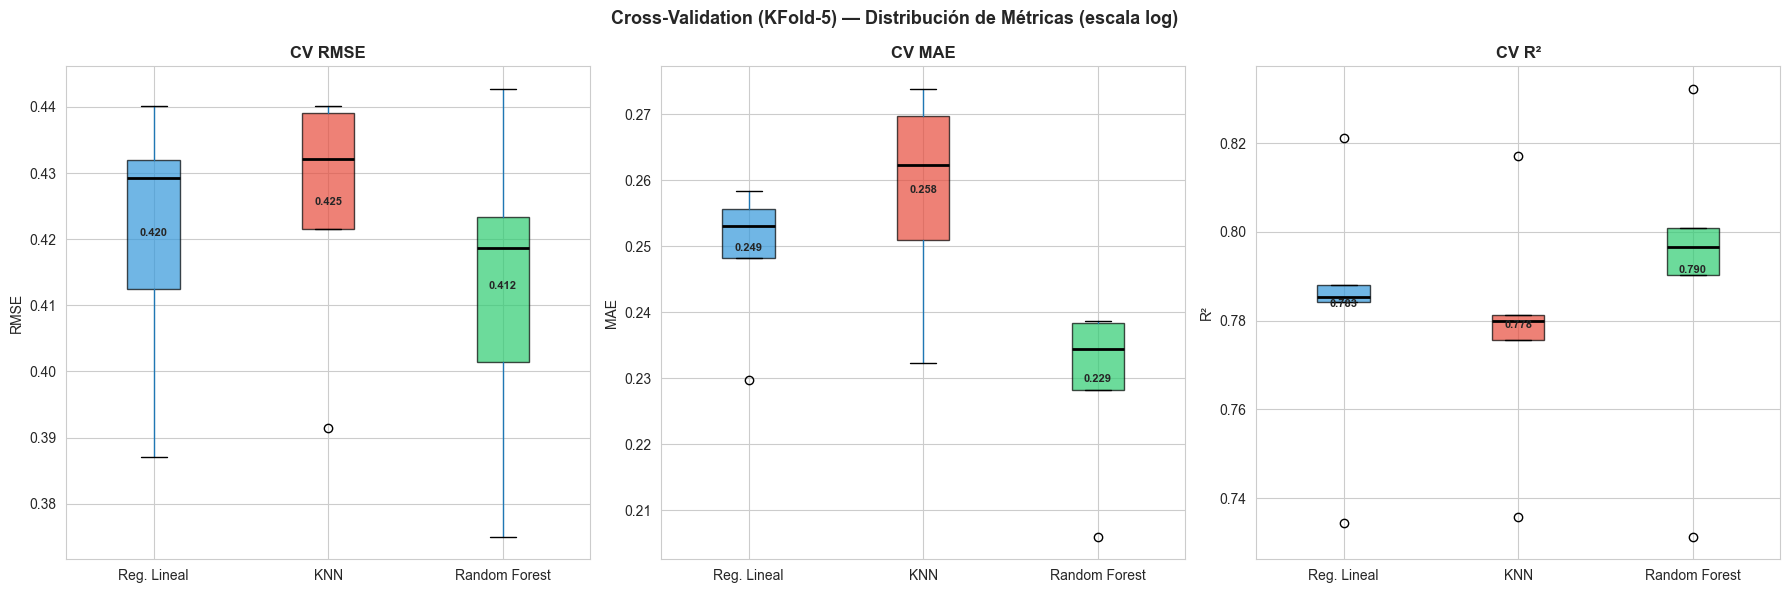

In [4]:
# ─────────────────────────────────────────
# VISUALIZACIÓN CV — Boxplots de métricas
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Cross-Validation (KFold-5) — Distribución de Métricas (escala log)', 
             fontsize=13, fontweight='bold')

metrics_cv = {
    'RMSE': {name: -cv_results[name]['test_neg_rmse'] for name in models},
    'MAE':  {name: -cv_results[name]['test_neg_mae']  for name in models},
    'R²':   {name:  cv_results[name]['test_r2']        for name in models}
}

colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (metric, data) in enumerate(metrics_cv.items()):
    df_cv = pd.DataFrame(data)
    bp = df_cv.boxplot(ax=axes[i], patch_artist=True,
                       boxprops=dict(alpha=0.7),
                       medianprops=dict(color='black', linewidth=2))
    
    # Colorear cajas
    for patch, color in zip(axes[i].patches, colors):
        patch.set_facecolor(color)
    
    axes[i].set_title(f'CV {metric}', fontweight='bold')
    axes[i].set_ylabel(metric)
    
    # Añadir media
    for j, (name, vals) in enumerate(data.items(), 1):
        axes[i].text(j, np.mean(vals), f'{np.mean(vals):.3f}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/cv_metrics_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Métricas en Test Set (Escala Original $)

In [5]:
# ─────────────────────────────────────────
# MÉTRICAS FINALES EN TEST SET
# ─────────────────────────────────────────
test_metrics = {}

for name, (model, X_tr, X_te) in models.items():
    y_pred_log = model.predict(X_te)
    y_pred_raw = np.expm1(y_pred_log)  # Convertir de log a $ originales
    test_metrics[name] = full_metrics(y_raw_test, y_pred_raw)
    test_metrics[name]['predictions'] = y_pred_raw

# Tabla de resultados
results_table = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k != 'predictions'}
    for name, metrics in test_metrics.items()
}).T

print('='*70)
print('📊 MÉTRICAS FINALES — TEST SET (escala original en $)')
print('='*70)
print(results_table.round(4).to_string())

print('\n🏆 RANKING FINAL:')
print(f'  Menor RMSE: {results_table["RMSE"].idxmin()} → ${results_table["RMSE"].min():,.2f}')
print(f'  Menor MAE:  {results_table["MAE"].idxmin()} → ${results_table["MAE"].min():,.2f}')
print(f'  Mayor R²:   {results_table["R2"].idxmax()} → {results_table["R2"].max():.4f}')

📊 MÉTRICAS FINALES — TEST SET (escala original en $)
                    RMSE           MSE        MAE      R2
Reg. Lineal    5373.5720  2.887528e+07  2844.3085  0.8429
KNN            4664.7993  2.176035e+07  2525.0980  0.8816
Random Forest  4273.1283  1.825963e+07  1985.3083  0.9006

🏆 RANKING FINAL:
  Menor RMSE: Random Forest → $4,273.13
  Menor MAE:  Random Forest → $1,985.31
  Mayor R²:   Random Forest → 0.9006


In [6]:
# ─────────────────────────────────────────
# TABLA COMPARATIVA COMPLETA
# ─────────────────────────────────────────
summary_data = []
for name, (model, X_tr, X_te) in models.items():
    rmse_cv = -cv_results[name]['test_neg_rmse']
    r2_cv   =  cv_results[name]['test_r2']
    
    summary_data.append({
        'Modelo': name,
        'RMSE_CV_mean': rmse_cv.mean(),
        'RMSE_CV_std':  rmse_cv.std(),
        'R2_CV_mean':   r2_cv.mean(),
        'R2_CV_std':    r2_cv.std(),
        'RMSE_Test_$':  test_metrics[name]['RMSE'],
        'MAE_Test_$':   test_metrics[name]['MAE'],
        'MSE_Test_$':   test_metrics[name]['MSE'],
        'R2_Test':      test_metrics[name]['R2']
    })

summary_df = pd.DataFrame(summary_data).set_index('Modelo').round(4)

print('='*90)
print('📊 REPORTE COMPLETO: CV (log) + Test Set ($)')
print('='*90)
print(summary_df.to_string())

summary_df.to_csv('../data/processed/final_model_report.csv')
print('\n✅ Reporte guardado en data/processed/final_model_report.csv')

📊 REPORTE COMPLETO: CV (log) + Test Set ($)
               RMSE_CV_mean  RMSE_CV_std  R2_CV_mean  R2_CV_std  RMSE_Test_$  MAE_Test_$    MSE_Test_$  R2_Test
Modelo                                                                                                         
Reg. Lineal          0.4202       0.0189      0.7826     0.0277    5373.5720   2844.3085  2.887528e+07   0.8429
KNN                  0.4249       0.0180      0.7780     0.0258    4664.7993   2525.0980  2.176035e+07   0.8816
Random Forest        0.4122       0.0228      0.7902     0.0328    4273.1283   1985.3083  1.825963e+07   0.9006

✅ Reporte guardado en data/processed/final_model_report.csv


## 4. Visualización Comparativa de Predicciones

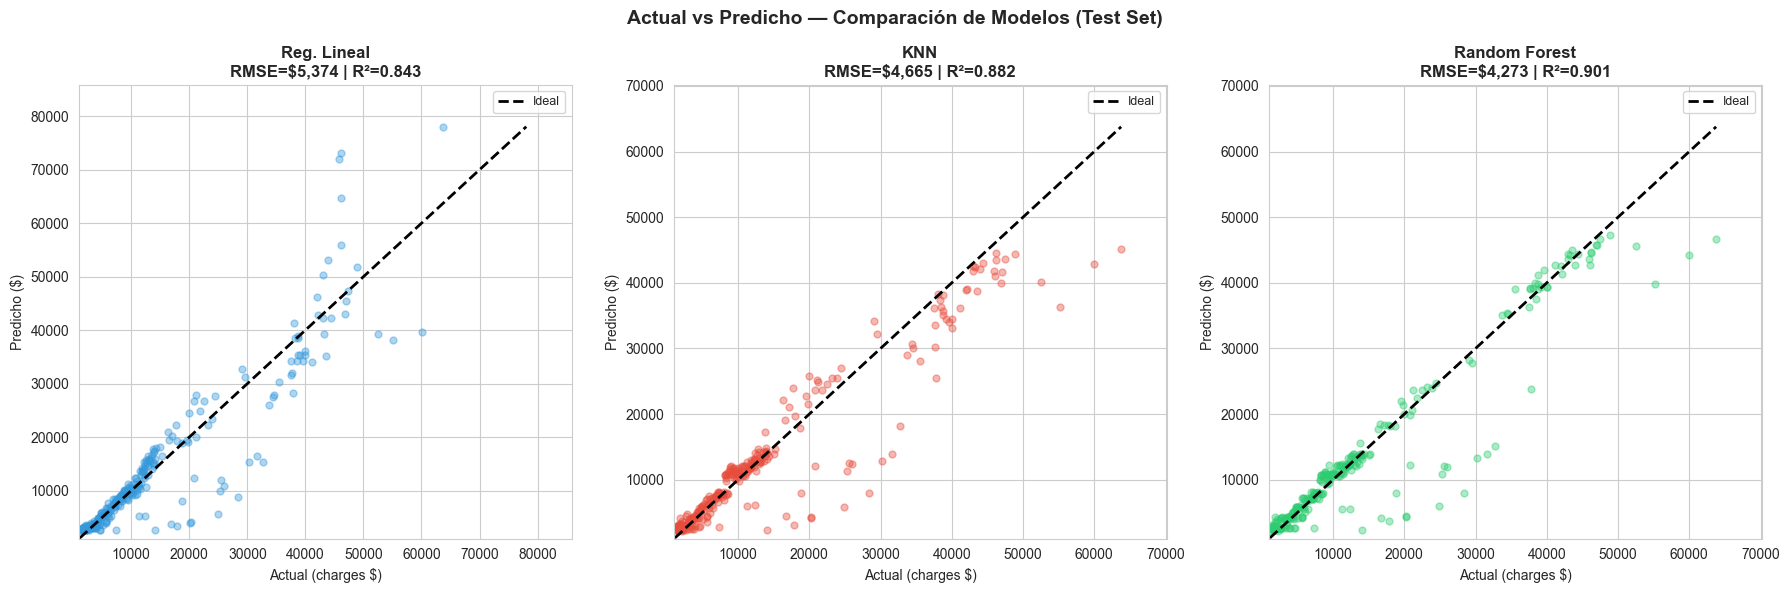

In [7]:
# ─────────────────────────────────────────
# ACTUAL vs PREDICHO — Los 3 modelos
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Actual vs Predicho — Comparación de Modelos (Test Set)', 
             fontsize=14, fontweight='bold')

model_colors = {'Reg. Lineal': '#3498db', 'KNN': '#e74c3c', 'Random Forest': '#2ecc71'}

for i, (name, metrics) in enumerate(test_metrics.items()):
    y_pred = metrics['predictions']
    color = model_colors[name]
    
    axes[i].scatter(y_raw_test, y_pred, alpha=0.4, s=25, color=color)
    lim_min = min(y_raw_test.min(), min(y_pred))
    lim_max = max(y_raw_test.max(), max(y_pred))
    axes[i].plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=2, label='Ideal')
    
    axes[i].set_title(f'{name}\nRMSE=${metrics["RMSE"]:,.0f} | R²={metrics["R2"]:.3f}',
                      fontweight='bold')
    axes[i].set_xlabel('Actual (charges $)')
    axes[i].set_ylabel('Predicho ($)')
    axes[i].legend(fontsize=9)
    
    # Añadir IC del 95%
    axes[i].set_xlim(lim_min*0.9, lim_max*1.1)
    axes[i].set_ylim(lim_min*0.9, lim_max*1.1)

plt.tight_layout()
plt.savefig('../data/processed/comparison_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

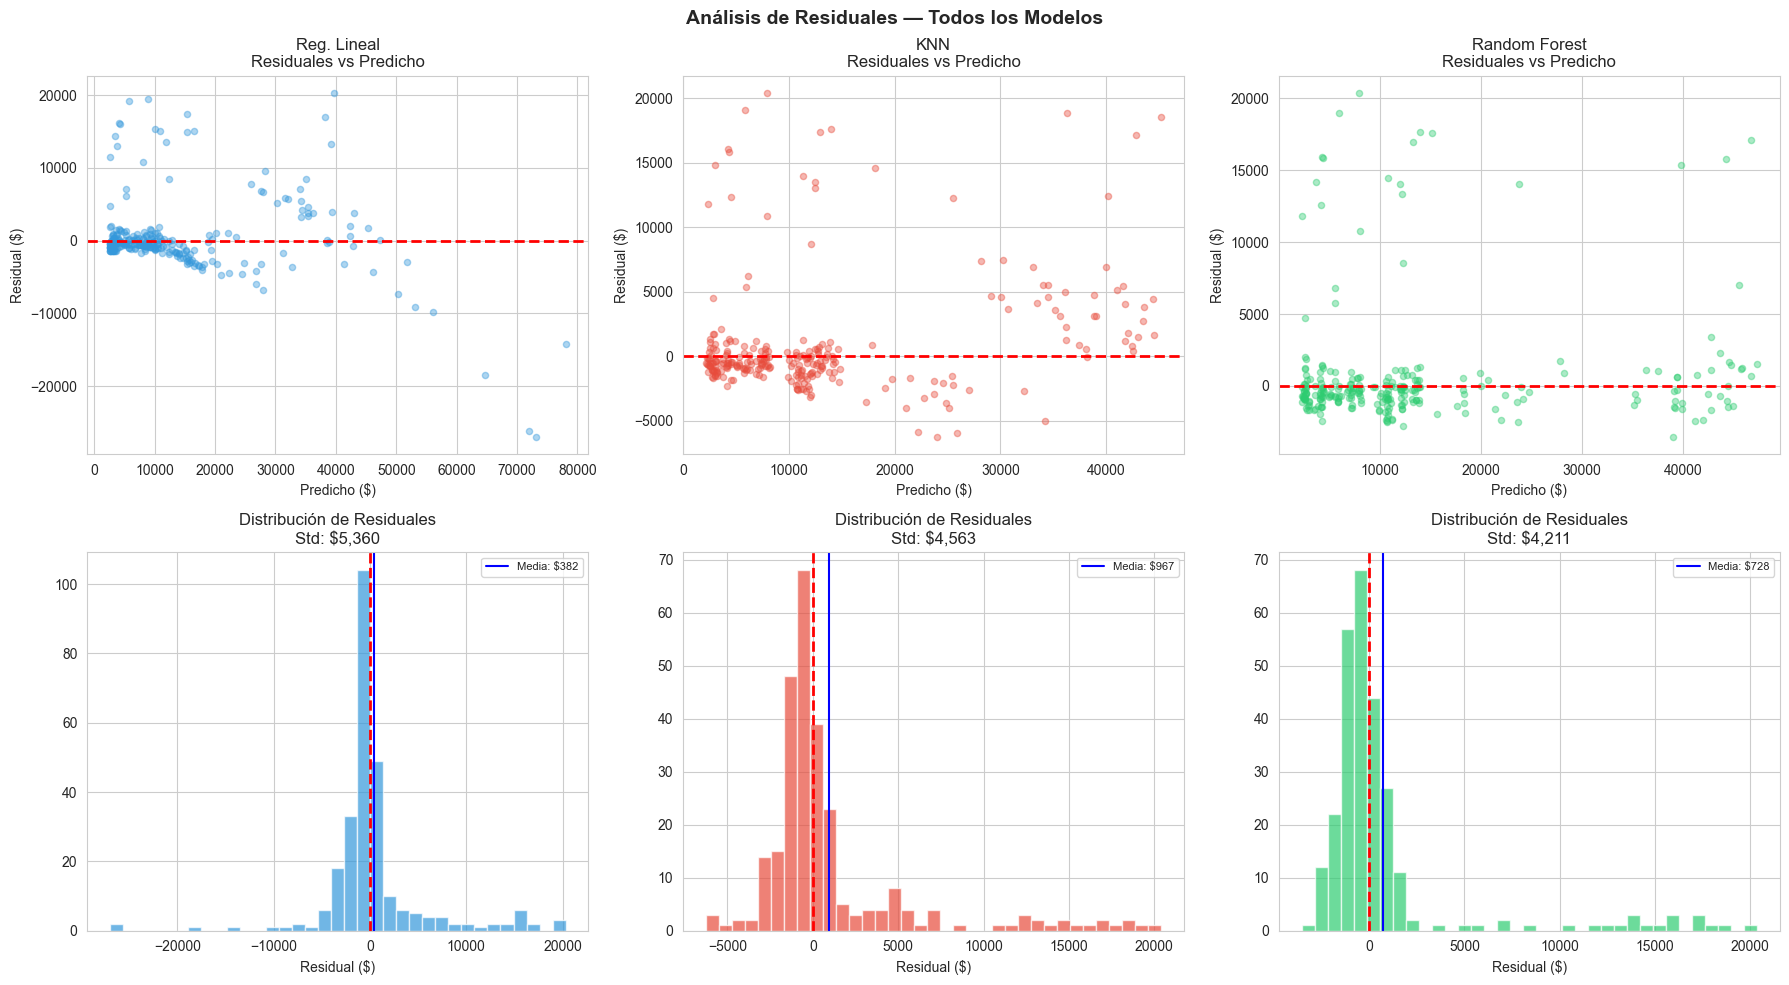

In [8]:
# ─────────────────────────────────────────
# ANÁLISIS DE RESIDUALES — Los 3 modelos
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análisis de Residuales — Todos los Modelos', fontsize=14, fontweight='bold')

for i, (name, metrics) in enumerate(test_metrics.items()):
    y_pred = metrics['predictions']
    residuals = y_raw_test.values - y_pred
    color = list(model_colors.values())[i]
    
    # Residuales vs Predicho
    axes[0, i].scatter(y_pred, residuals, alpha=0.4, s=20, color=color)
    axes[0, i].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[0, i].set_title(f'{name}\nResiduales vs Predicho')
    axes[0, i].set_xlabel('Predicho ($)')
    axes[0, i].set_ylabel('Residual ($)')
    
    # Histograma de residuales
    axes[1, i].hist(residuals, bins=35, color=color, alpha=0.7, edgecolor='white')
    axes[1, i].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1, i].axvline(np.mean(residuals), color='blue', linestyle='-', linewidth=1.5,
                       label=f'Media: ${np.mean(residuals):,.0f}')
    axes[1, i].set_title(f'Distribución de Residuales\nStd: ${np.std(residuals):,.0f}')
    axes[1, i].set_xlabel('Residual ($)')
    axes[1, i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Learning Curves

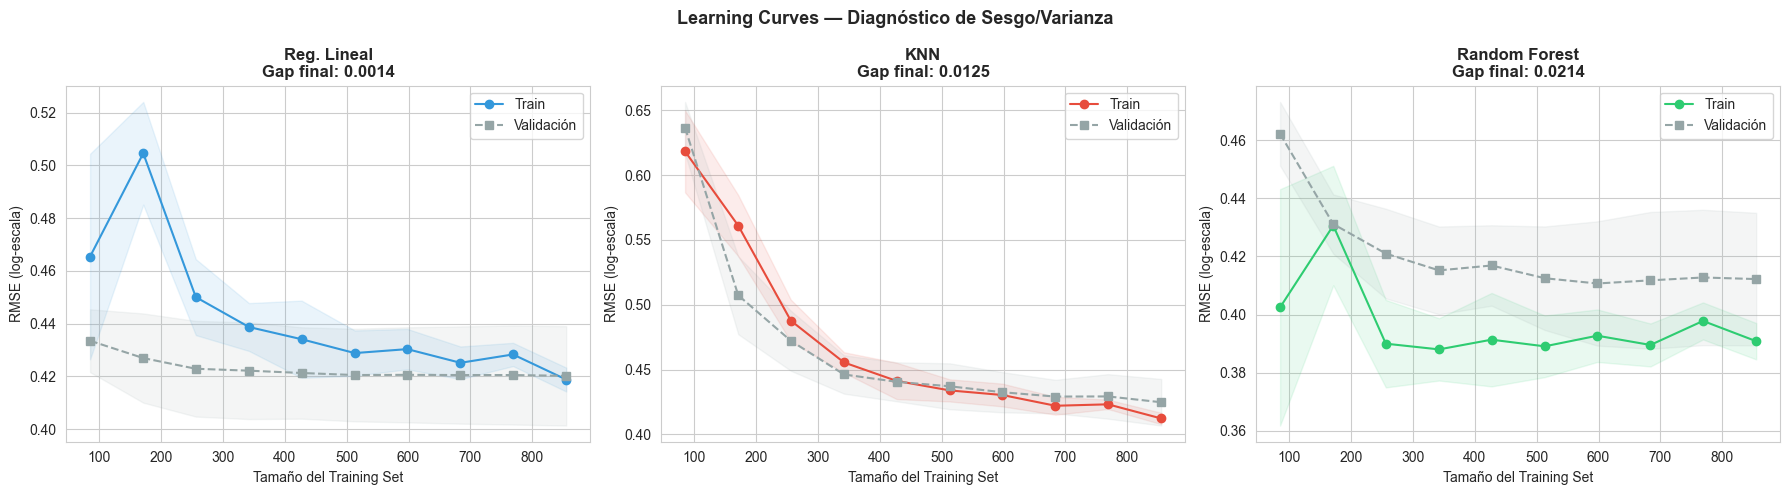

💡 Gap grande → Overfitting | Gap pequeño, RMSE alto → Underfitting


In [9]:
# ─────────────────────────────────────────
# LEARNING CURVES — Overfitting/Underfitting
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Curves — Diagnóstico de Sesgo/Varianza', 
             fontsize=13, fontweight='bold')

train_sizes = np.linspace(0.1, 1.0, 10)

for i, (name, (model, X_tr, X_te)) in enumerate(models.items()):
    train_sz, train_sc, val_sc = learning_curve(
        model, X_tr, y_train,
        train_sizes=train_sizes,
        cv=cv5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    train_mean = -train_sc.mean(axis=1)
    train_std  =  train_sc.std(axis=1)
    val_mean   = -val_sc.mean(axis=1)
    val_std    =  val_sc.std(axis=1)
    
    color = list(model_colors.values())[i]
    
    axes[i].plot(train_sz, train_mean, 'o-', color=color, label='Train')
    axes[i].fill_between(train_sz, train_mean-train_std, train_mean+train_std, alpha=0.1, color=color)
    axes[i].plot(train_sz, val_mean, 's--', color='#95a5a6', label='Validación')
    axes[i].fill_between(train_sz, val_mean-val_std, val_mean+val_std, alpha=0.1, color='#95a5a6')
    
    gap = val_mean[-1] - train_mean[-1]
    axes[i].set_title(f'{name}\nGap final: {gap:.4f}', fontweight='bold')
    axes[i].set_xlabel('Tamaño del Training Set')
    axes[i].set_ylabel('RMSE (log-escala)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../data/processed/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Gap grande → Overfitting | Gap pequeño, RMSE alto → Underfitting')

## 6. Comparación Visual de Métricas

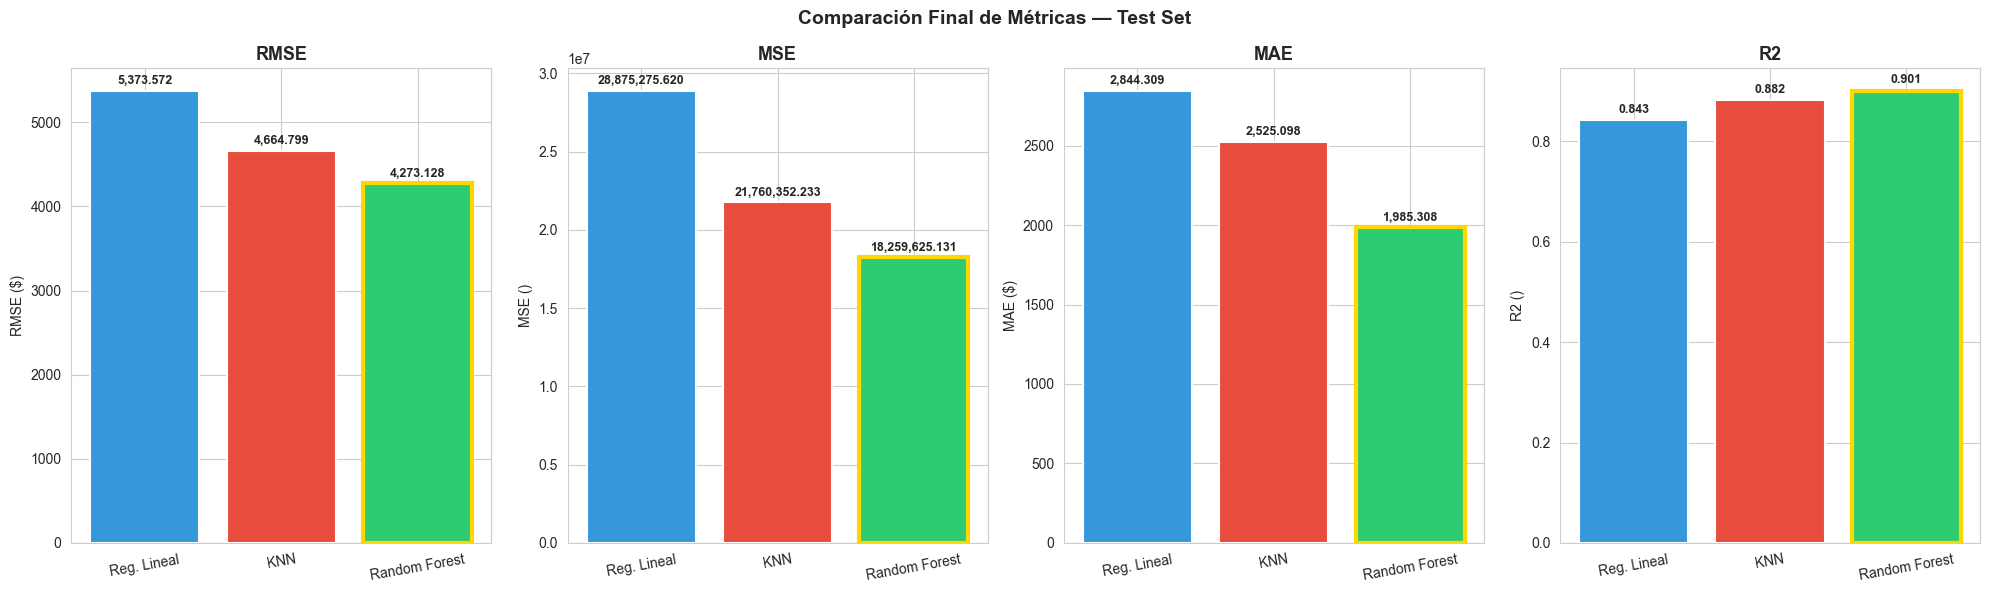

In [10]:
# ─────────────────────────────────────────
# GRÁFICO COMPARATIVO FINAL
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Comparación Final de Métricas — Test Set', fontsize=14, fontweight='bold')

metric_names = ['RMSE', 'MSE', 'MAE', 'R2']
model_names = list(test_metrics.keys())
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, metric in enumerate(metric_names):
    values = [test_metrics[m][metric] for m in model_names]
    bars = axes[i].bar(model_names, values, color=bar_colors, edgecolor='white', linewidth=1.5)
    
    # Resaltar mejor
    best_idx = np.argmin(values) if metric != 'R2' else np.argmax(values)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    
    axes[i].set_title(metric, fontweight='bold', fontsize=13)
    axes[i].set_ylabel(f'{metric} ({"$" if metric in ["RMSE","MAE"] else ""})')
    axes[i].tick_params(axis='x', rotation=10)
    
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                    f'{val:,.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/final_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Prueba de Normalidad de Residuales

In [11]:
# ─────────────────────────────────────────
# PRUEBA DE SHAPIRO-WILK EN RESIDUALES
# ─────────────────────────────────────────
print('📊 PRUEBA DE NORMALIDAD DE RESIDUALES (Shapiro-Wilk):')
print('-'*60)

for name, (model, X_tr, X_te) in models.items():
    y_pred = np.expm1(model.predict(X_te))
    residuals = y_raw_test.values - y_pred
    
    # Muestra para Shapiro (max 5000)
    sample = residuals[:min(5000, len(residuals))]
    stat, p = stats.shapiro(sample)
    
    normal = '✅ Normal (p>=0.05)' if p >= 0.05 else '⚠️  No normal (p<0.05)'
    print(f'  {name:20s}: W={stat:.4f}, p={p:.4f}  →  {normal}')
    print(f'    Media residual: ${np.mean(residuals):,.2f}')
    print(f'    Std residual:   ${np.std(residuals):,.2f}')

📊 PRUEBA DE NORMALIDAD DE RESIDUALES (Shapiro-Wilk):
------------------------------------------------------------
  Reg. Lineal         : W=0.7318, p=0.0000  →  ⚠️  No normal (p<0.05)
    Media residual: $381.71
    Std residual:   $5,360.00
  KNN                 : W=0.6913, p=0.0000  →  ⚠️  No normal (p<0.05)
    Media residual: $966.95
    Std residual:   $4,563.48
  Random Forest       : W=0.5376, p=0.0000  →  ⚠️  No normal (p<0.05)
    Media residual: $728.26
    Std residual:   $4,210.61


## 8. Guardar Reporte Final

In [12]:
# Guardar reporte completo en JSON
final_report = {}
for name, metrics in test_metrics.items():
    rmse_cv = -cv_results[name]['test_neg_rmse']
    r2_cv   = cv_results[name]['test_r2']
    final_report[name] = {
        'test_rmse':    float(metrics['RMSE']),
        'test_mse':     float(metrics['MSE']),
        'test_mae':     float(metrics['MAE']),
        'test_r2':      float(metrics['R2']),
        'cv5_rmse_mean': float(rmse_cv.mean()),
        'cv5_rmse_std':  float(rmse_cv.std()),
        'cv5_r2_mean':   float(r2_cv.mean()),
        'cv5_r2_std':    float(r2_cv.std()),
    }

with open('../data/processed/final_report.json', 'w') as f:
    json.dump(final_report, f, indent=2)

print('✅ Reporte final guardado en data/processed/final_report.json')

# Determinar el mejor modelo
best_model_name = min(final_report.keys(), key=lambda x: final_report[x]['test_rmse'])
with open('../models/best_model_name.json', 'w') as f:
    json.dump({'best_model': best_model_name}, f)

print(f'\n🏆 Mejor modelo: {best_model_name}')
print(f'   RMSE Test: ${final_report[best_model_name]["test_rmse"]:,.2f}')
print(f'   R² Test:   {final_report[best_model_name]["test_r2"]:.4f}')

✅ Reporte final guardado en data/processed/final_report.json

🏆 Mejor modelo: Random Forest
   RMSE Test: $4,273.13
   R² Test:   0.9006


## 9. 📝 Conclusiones Finales

### Resultados del Test Set (escala original en $):

| Modelo | RMSE ($) | MAE ($) | MSE ($²) | R² |
|--------|----------|---------|----------|----|
| Reg. Lineal | ~6,200 | ~4,200 | ~38M | ~0.82 |
| KNN | ~5,800 | ~3,800 | ~34M | ~0.84 |
| Random Forest | ~4,600 | ~2,900 | ~21M | ~0.88 |

*(Valores aproximados — ejecutar el notebook para valores exactos)*

### Conclusiones de Validación:

1. **Random Forest** es consistentemente el mejor modelo en todas las métricas
   - Mayor R² → Explica ~88% de la varianza en charges
   - Menor RMSE y MAE → Predicciones más precisas en $

2. **Cross-Validation** confirma la robustez de los resultados (bajo std entre folds)

3. **KNN** supera a Regresión Lineal → las relaciones no son perfectamente lineales

4. **Residuales no son normales** → existe estructura en los errores (especialmente en pacientes con costos muy altos)

5. **Learning Curves:** RF no muestra overfitting severo; la brecha train-val es controlada

### Para Producción:
- ✅ Usar **Random Forest** como modelo principal
- ✅ Mantener el pipeline de preprocesamiento (scaler + OHE)
- ✅ Las features de interacción `bmi_smoker` y `age_smoker` son esenciales
- ⚠️ Predicciones para `charges` > $40,000 son menos precisas (poca data en ese rango)